<a href="https://colab.research.google.com/github/Doclikam/DS4H/blob/main/Notebooks/Cardiotocographic_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Processing Cardiotocographic Recordings**

.**The fetal heart rate**

• **The uterine contraction signal**

• **Maternal data**: age, parity, gravidity

• **Delivery data**: type of delivery (vaginal; operative vaginal; Cesarean section), duration of
delivery, meconium-stained fluid, type of measurement (i.e., ultrasound or direct scalp
electrode)

•**Fetal data:** sex, birth weight

• **Fetal outcome data**: analysis of umbilical artery blood sample (i.e., pH; pCO₂; pO₂; base
excess and computed BDecf); Apgar score; neonatology evaluation (i.e., need for O₂,
seizures, NICU admission)

In [1]:
pip install wfdb --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
!pip install physionet --quiet

In [3]:
!wget -r -N -c -np https://physionet.org/files/ctu-uhb-ctgdb/1.0.0/.      --quiet

In [4]:
#import libraries
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
import os
from collections import Counter
from scipy.stats import entropy
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [6]:
#find path to file
!find /content -name "1001.hea"

/content/physionet.org/files/ctu-uhb-ctgdb/1.0.0/1001.hea


In [7]:
record=wfdb.rdrecord('/content/physionet.org/files/ctu-uhb-ctgdb/1.0.0/1001')
print(record.sig_name)
print(record.p_signal.shape)
print("Sampling Frequency:", record.fs)
print("Units of measurement:", record.units)

['FHR', 'UC']
(19200, 2)
Sampling Frequency: 4
Units of measurement: ['bpm', 'nd']


In [8]:
heads= wfdb.rdheader("/content/physionet.org/files/ctu-uhb-ctgdb/1.0.0/1001")
print(heads.comments)

['----- Additional parameters for record 1001', '-- Outcome measures', 'pH           7.14', 'BDecf        8.14', 'pCO2         7.7', 'BE           -10.5', 'Apgar1       6', 'Apgar5       8', '-- !NotReadyYet! Neonatology outcome measures !NotReadyYet!', 'NICU days    0', 'Seizures     0', 'HIE          0', 'Intubation   0', 'Main diag.   0', 'Other diag.  0', '-- Fetus/Neonate descriptors', 'Gest. weeks  37', 'Weight(g)    2660', 'Sex          2', '-- Maternal (risk-)factors', 'Age          32', 'Gravidity    1', 'Parity       0', 'Diabetes     1', 'Hypertension 0', 'Preeclampsia 0', 'Liq. praecox 1', 'Pyrexia      0', 'Meconium     0', '-- Delivery descriptors', 'Presentation 2', 'Induced      0', 'I.stage      232', 'NoProgress   0', 'CK/KP        0', 'II.stage     20', 'Deliv. type  1', '-- Signal information', 'dbID         974204', 'Rec. type    1', 'Pos. II.st.  14400', 'Sig2Birth    0']


In [9]:
#get records
base_url = "/content/physionet.org/files/ctu-uhb-ctgdb/1.0.0"
files =[f for f in os.listdir(base_url) if f.endswith(".hea")]
records = [f.replace(".hea", "") for f in files]
print(f"Total records found: {len(records)}")

Total records found: 552


In [10]:
#function yto get the records
def get_delivery(record_name):
  header = wfdb.rdheader(record_name)
  for line in header.comments:
    if line.strip().startswith("Deliv. type"):
      return int(line.split()[-1])
  return None

vaginal_delivery = []
delivery_types = []

for r in records:
  rec_path = f"{base_url}/{r}"
  d_type = get_delivery(rec_path)
  if d_type is not None:
    delivery_types.append(d_type)
    if d_type !=2:
      vaginal_delivery.append(r)

print("Total Deliveries: ")
print(Counter(delivery_types))
print(f"Vaginal Deliveries: {len(vaginal_delivery)}")

Total Deliveries: 
Counter({1: 506, 2: 46})
Vaginal Deliveries: 506


In [11]:
print(vaginal_delivery)

['1480', '1199', '1046', '1007', '1387', '1475', '1191', '1124', '1027', '1376', '1028', '1095', '1066', '1054', '1346', '1439', '1349', '1433', '1355', '1051', '1321', '1274', '1354', '1428', '1277', '1221', '1195', '1452', '1343', '1317', '1166', '1328', '1417', '1310', '1184', '1348', '1385', '1106', '1459', '1077', '1365', '1505', '1092', '1104', '1307', '1115', '1123', '1236', '1129', '1265', '1296', '1238', '1024', '1260', '1242', '1359', '1465', '1284', '1015', '1396', '1494', '1286', '1268', '1002', '1474', '1072', '1384', '1229', '1008', '1340', '1212', '1383', '1341', '1131', '1192', '1497', '1146', '1256', '1233', '1443', '1016', '1033', '1185', '1213', '1075', '1367', '1139', '1303', '1399', '1461', '1175', '1487', '1031', '1038', '1267', '1111', '1232', '1289', '1371', '1463', '1391', '1468', '1424', '1293', '1308', '1421', '1436', '1039', '1263', '1493', '1223', '1044', '1420', '1243', '1057', '1093', '1469', '1247', '1485', '1150', '1458', '1156', '1395', '1157', '1145',

In [12]:
#idenmyify the signals that have more >10% missing values

def zero_signal(signal):
  return np.mean(signal == 0)

  #list of records with <10% non zeros
quality_records =[]

for r in vaginal_delivery:
    record = wfdb.rdrecord(f"{base_url}/{r}")
    fetal_heart_rate=record.p_signal[:,0]
    if zero_signal(fetal_heart_rate) <= 0.10:
      quality_records.append(r)

print(f"Total Quality records with <10% zero signals:{len(quality_records)}")

Total Quality records with <10% zero signals:151


In [13]:
#remove the zero values
def discard_zeros(signal):
  return signal[signal!=0]


#feature extarction
def extract_ph(record_name):
  header = wfdb.rdheader(record_name)
  for line in header.comments:
    if line.strip().startswith('pH'):
      return float(line.split()[-1])
  return None
#store ph labels
labels = {}
ph_values = []

for r in quality_records:
  rec_path = f"{base_url}/{r}"
  ph = extract_ph(rec_path)

  if ph is not None:
    ph_values.append(ph)

  if ph>=7.2 and ph<= 7.35:
        labels[r] =1 #normal PH
  else:
        labels[r] = 0 #abnormal ph

print("Min pH:", min(ph_values))
print("Max pH:", max(ph_values))
print("Unique pH values (first 10):", sorted(ph_values)[:10])
print("class distribution:", Counter(labels.values()))


Min pH: 6.92
Max pH: 7.43
Unique pH values (first 10): [6.92, 6.95, 7.03, 7.07, 7.09, 7.1, 7.11, 7.11, 7.11, 7.12]
class distribution: Counter({1: 98, 0: 53})


In [27]:
#get RMSSD---> Root Mean Square Successive Difeerences
def rmssd(signal):
  return np.sqrt(np.mean(np.diff(signal)**2))

#get shannon entropy
def shanon_entropy(signal, bins=50):
  hist, _ = np.histogram(signal, bins=bins, density =True)
  hist = hist[hist>0]
  return entropy(hist)

#extract features
#get the mean, std, rmsssd, shanon_entropy
def extract_features(signal):
  [np.mean(signal),
  np.std(signal),
  rmssd(signal),
  shanon_entropy(signal)]


In [19]:
print(labels)

{'1046': 1, '1387': 1, '1346': 1, '1439': 1, '1274': 0, '1221': 1, '1195': 1, '1317': 1, '1166': 1, '1348': 0, '1385': 1, '1459': 1, '1505': 1, '1104': 0, '1307': 1, '1115': 0, '1123': 1, '1129': 1, '1024': 0, '1359': 0, '1494': 0, '1229': 0, '1008': 0, '1340': 1, '1212': 1, '1341': 0, '1192': 1, '1033': 1, '1303': 0, '1399': 1, '1175': 1, '1031': 1, '1111': 1, '1371': 0, '1391': 1, '1468': 0, '1308': 0, '1420': 1, '1485': 0, '1157': 0, '1177': 1, '1479': 1, '1457': 0, '1245': 0, '1126': 0, '1283': 1, '1224': 1, '1342': 1, '1368': 1, '1393': 0, '1456': 1, '1194': 1, '1416': 0, '1454': 1, '1294': 1, '1259': 1, '1389': 1, '1069': 1, '1208': 1, '1149': 1, '1319': 1, '1025': 1, '1193': 1, '1019': 0, '1388': 1, '1207': 1, '1272': 1, '1298': 1, '1109': 1, '1127': 1, '1020': 0, '1450': 1, '1197': 0, '1397': 1, '1103': 1, '1491': 0, '1489': 1, '1292': 1, '1322': 0, '1290': 0, '1426': 0, '1230': 0, '1045': 1, '1412': 1, '1437': 0, '1400': 0, '1161': 0, '1331': 0, '1464': 1, '1035': 1, '1257': 1

In [41]:
# RMSSD: Root Mean Square of Successive Differences
def rmssd(signal):
    return np.sqrt(np.mean(np.diff(signal) ** 2))

# Shannon entropy
def shannon_entropy(signal, bins=50):
    hist, _ = np.histogram(signal, bins=bins, density=True)
    hist = hist[hist > 0]
    return entropy(hist)

# Feature extraction
def extract_features(signal):
    # Safety check: avoid NaNs
    if len(signal) < 10:
        return None

    return [
        np.mean(signal),
        np.std(signal),
        rmssd(signal),
        shannon_entropy(signal)
    ]

In [42]:
#build an matrix X and a label vector y
X = []
y = []


for f, label in labels.items():
  record = wfdb.rdrecord(f"{base_url}/{f}")
  fhr = record.p_signal[:,0]
  fhr = fhr[fhr!=0]

  features = extract_features(fhr)

  X.append(features)
  y.append(label)

X = np.array(X, dtype=float)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (151, 4)
Labels shape: (151,)


In [45]:
#kNN
ks = range(3,42,2)
accuracies = []

for k in ks:
  knn = KNeighborsClassifier(n_neighbors=k)
  acc = cross_val_score(knn, X, y, cv=5).mean()
  accuracies.append(acc)

for k, acc in zip(ks, accuracies):
  print(f"k = {k:2d} | accuracy = {acc:.3f}")

k =  3 | accuracy = 0.615
k =  5 | accuracy = 0.629
k =  7 | accuracy = 0.669
k =  9 | accuracy = 0.669
k = 11 | accuracy = 0.636
k = 13 | accuracy = 0.629
k = 15 | accuracy = 0.617
k = 17 | accuracy = 0.603
k = 19 | accuracy = 0.590
k = 21 | accuracy = 0.603
k = 23 | accuracy = 0.603
k = 25 | accuracy = 0.616
k = 27 | accuracy = 0.629
k = 29 | accuracy = 0.642
k = 31 | accuracy = 0.642
k = 33 | accuracy = 0.649
k = 35 | accuracy = 0.649
k = 37 | accuracy = 0.649
k = 39 | accuracy = 0.649
k = 41 | accuracy = 0.649


In [48]:
X_no_mean = X[:, 1:]
accuracies_no_mean = []

for k in ks:
  knn = KNeighborsClassifier(n_neighbors = k)
  acc = cross_val_score(knn, X_no_mean, y, cv=5).mean()
  accuracies_no_mean.append(acc)

print("\nAfter removing mean feature:\n")

for k, acc in zip(ks, accuracies_no_mean):
    print(f"k = {k:2d} | accuracy = {acc:.3f}")


After removing mean feature:

k =  3 | accuracy = 0.563
k =  5 | accuracy = 0.589
k =  7 | accuracy = 0.603
k =  9 | accuracy = 0.596
k = 11 | accuracy = 0.569
k = 13 | accuracy = 0.583
k = 15 | accuracy = 0.570
k = 17 | accuracy = 0.583
k = 19 | accuracy = 0.603
k = 21 | accuracy = 0.630
k = 23 | accuracy = 0.616
k = 25 | accuracy = 0.610
k = 27 | accuracy = 0.617
k = 29 | accuracy = 0.623
k = 31 | accuracy = 0.603
k = 33 | accuracy = 0.623
k = 35 | accuracy = 0.610
k = 37 | accuracy = 0.616
k = 39 | accuracy = 0.629
k = 41 | accuracy = 0.636


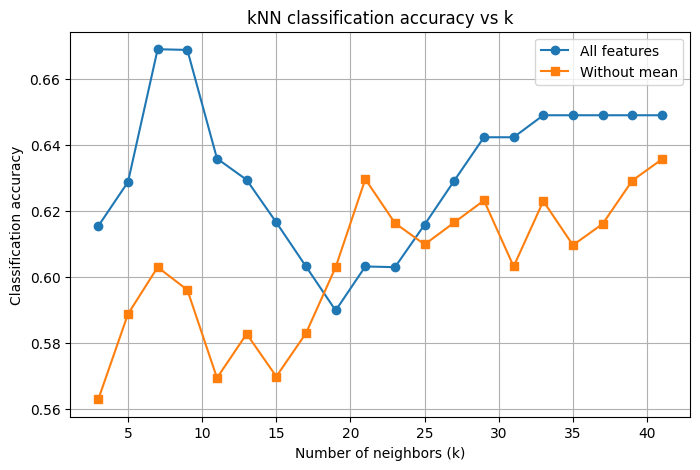

In [50]:
#plot accuracy

plt.figure(figsize=(8,5))
plt.plot(ks, accuracies, marker='o', label='All features')
plt.plot(ks, accuracies_no_mean, marker='s', label='Without mean')
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Classification accuracy")
plt.title("kNN classification accuracy vs k")
plt.legend()
plt.grid(True)
plt.show()
